# Project: Multimodal Product Classification using Autogluon Library

# The Goal - Predict the Product Category (Multi Class) using a fusion of product images and text descriptions.

# The Dataset: Amazon Berkeley Objects (https://amazon-berkeley-objects.s3.amazonaws.com/index.html)

## The Data:
  * Images: abo-images-small.tar (3 GB)
  * Labels: abo-listings.tar — Product listings and metadata (83 Mb)

In [6]:
import torch
import numpy as np
import pandas as pd
import os
from pathlib import Path
import json
import gzip
import transformers
from platform import python_version

from autogluon.tabular import TabularPredictor

print(f"--- Environment Report ---")
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"Current device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Python version: {python_version()}")
print(f"NumPy: {np.__version__}")
print(f"Torch: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

# Test AutoGluon
try:
    print(f"AutoGluon: TabularPredictor imported!")
except Exception as e:
    print(f"AutoGluon Error: {e}")

--- Environment Report ---
Is CUDA available? True
Current device: NVIDIA GeForce RTX 5070 Laptop GPU
Python version: 3.10.19
NumPy: 1.26.4
Torch: 2.9.1+cu128
Transformers version: 4.57.6
AutoGluon: TabularPredictor imported!


In [8]:
#!pip install autogluon.multimodal
import autogluon.multimodal
from autogluon.multimodal import MultiModalPredictor

# Check version
print(f"AutoGluon Multimodal version: {autogluon.multimodal.__version__}")

# Check if it can initialize a dummy predictor
try:
    predictor = MultiModalPredictor(label="label")
    print("Installation verified: Predictor initialized successfully.")
except Exception as e:
    print(f"Initialization failed: {e}")

AutoGluon Multimodal version: 1.5.0
Installation verified: Predictor initialized successfully.


# Data Engineering

In [5]:
# Amazon Berkeley Objects (ABO) dataset - multimodal data - images + texts
# abo-images-small.tar — Downscaled (max 256 pixels) catalog images and metadata (3 Gb)

import tarfile

tar_path = Path("Data/abo-images-small.tar")
output_dir = Path("Data/abo-images-small")

output_dir.mkdir(parents=True, exist_ok=True)

with tarfile.open(tar_path, "r") as tf:
    tf.extractall(path=output_dir)

print(f"Extracted {tar_path} to {output_dir}")

Extracted Data/abo-images-small.tar to Data/abo-images-small


In [10]:
# Paths based on local setup
base_path = Path("Data/abo-images-small")
metadata_path = base_path / "images/metadata/images.csv.gz" 

# Load Metadata - Most ABO image metadata maps 'image_id' to 'path'
df_metadata = pd.read_csv(metadata_path)

# Convert relative paths to absolute paths 
def complete_path(relative_path):
    return str((base_path / "images/small" / relative_path).resolve())

df_metadata['image_path'] = df_metadata['path'].apply(complete_path)

# Test if an image exists
sample_path = df_metadata['image_path'].iloc[0]
if os.path.exists(sample_path):
    print(f"Success! Found image path: {sample_path}")
else:
    print("Image not found.")

Success! Found image path: /home/maulik/CS104/Final/Data/abo-images-small/images/small/14/14fe8812.jpg


#### The Labels- AutoGluon is a supervised learning library, it needs a the label to understand 

In [6]:
# The listings_0.json.gz file contains the "answers" (labels) like product_type, brand, and main_category
# listing 0 has ~9000 items and all listings have ~90,000 items - tradeoff is long training and out of memory issues vs. not finding long-tail items.
# experimented with listings_0 and then added listings_0 and listings_1 and afterwards all listings! 

# Load the listings metadata
#listings_path = ["Data/listings_0.json.gz", "Data/listings_1.json.gz"]

#listings = []

#for path in listings_path:
#    with gzip.open(path, 'rt', encoding='utf-8') as f:
#        for line in f:
#            listings.append(json.loads(line))

#df_listings = pd.DataFrame(listings)

# Drop rows where we don't have a label or a name
#df_listings = df_listings.dropna(subset=['product_type', 'item_name', 'main_image_id'])

#print(f"Total rows loaded and cleaned: {len(df_listings)}")

#df_listings.head()

In [11]:
# Game-on - download and merge all the listings - 90,000 labels! 

# ran following once to get all 10 listings files on local disk
# !for i in {0..9}; do wget -P Data/ https://amazon-berkeley-objects.s3.amazonaws.com/listings/metadata/listings_$i.json.gz; done

import glob

# Find all listing files
listing_files = glob.glob("Data/listings_*.json.gz")
print(f"Found {len(listing_files)} files: {listing_files}")

# Combine all JSONs into the name df_listings
df_listings = pd.concat([pd.read_json(f, lines=True) for f in listing_files], ignore_index=True)

# Drop rows where we don't have a label or a name
df_listings = df_listings.dropna(subset=['product_type', 'item_name', 'main_image_id'])

print(f"Total rows loaded and cleaned: {len(df_listings)}")

df_listings.head()

Found 10 files: ['Data/listings_9.json.gz', 'Data/listings_2.json.gz', 'Data/listings_7.json.gz', 'Data/listings_1.json.gz', 'Data/listings_8.json.gz', 'Data/listings_4.json.gz', 'Data/listings_3.json.gz', 'Data/listings_5.json.gz', 'Data/listings_0.json.gz', 'Data/listings_6.json.gz']
Total rows loaded and cleaned: 91950


,item_dimensions,brand,bullet_point,color,item_id,item_name,item_shape,material,model_number,product_type,...,domain_name,item_weight,model_name,node,fabric_type,product_description,pattern,color_code,model_year,finish_type
0,{'height': {'normalized_value': {'unit': 'inch...,"[{'language_tag': 'en_US', 'value': 'Amazon Ba...","[{'language_tag': 'en_US', 'value': 'Standard ...","[{'language_tag': 'en_US', 'standardized_value...",B07Q9TDSGD,"[{'language_tag': 'en_US', 'value': 'Amazon Ba...","[{'language_tag': 'en_US', 'value': 'Rectangul...","[{'language_tag': 'en_US', 'value': 'Polypropy...",[{'value': 'ECHO1209-6X9'}],[{'value': 'RUG'}],...,amazon.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,"[{'language_tag': 'en_IN', 'value': 'Amazon Br...","[{'language_tag': 'en_IN', 'value': 'Snug fit ...","[{'language_tag': 'en_IN', 'standardized_value...",B08544GDRH,"[{'language_tag': 'en_IN', 'value': 'Amazon Br...",NaN,"[{'language_tag': 'en_IN', 'value': 'Silicon'}]",[{'value': 'UV10812-SL40308'}],[{'value': 'CELLULAR_PHONE_CASE'}],...,amazon.in,"[{'normalized_value': {'unit': 'pounds', 'valu...","[{'language_tag': 'en_IN', 'value': 'Tecno Spa...","[{'node_id': 12538061031, 'node_name': '/Categ...",NaN,NaN,NaN,NaN,NaN,NaN
2,{'height': {'normalized_value': {'unit': 'inch...,"[{'language_tag': 'en_US', 'value': 'Stone & B...","[{'language_tag': 'es_US', 'value': 'Completa ...","[{'language_tag': 'ko_KR', 'standardized_value...",B07BW8PZ4H,"[{'language_tag': 'ko_KR', 'value': 'Stone & B...",NaN,"[{'language_tag': 'zh_CN', 'value': '木头'}, {'l...",[{'value': 'D35100LLSECT'}],[{'value': 'HOME_FURNITURE_AND_DECOR'}],...,amazon.com,"[{'normalized_value': {'unit': 'pounds', 'valu...",NaN,"[{'node_id': 1063498, 'node_name': '/Categorie...","[{'language_tag': 'en_US', 'value': 'Slipcover...",NaN,NaN,NaN,NaN,NaN
3,{'height': {'normalized_value': {'unit': 'inch...,"[{'language_tag': 'en_US', 'value': 'Rivet'}]","[{'language_tag': 'en_US', 'value': '100% Wool...","[{'language_tag': 'zh_CN', 'standardized_value...",B075Z9SBGN,"[{'language_tag': 'zh_CN', 'value': 'Rivet Mot...","[{'language_tag': 'en_US', 'value': 'Rectangul...","[{'language_tag': 'zh_CN', 'value': '羊毛'}, {'l...",[{'value': 'ENN01DENIM2X8'}],[{'value': 'RUG'}],...,amazon.com,"[{'normalized_value': {'unit': 'pounds', 'valu...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,"[{'language_tag': 'fr_FR', 'value': 'Eono'}]","[{'language_tag': 'fr_FR', 'value': 'Conçu UNI...","[{'language_tag': 'fr_FR', 'standardized_value...",B0811XR8PS,"[{'language_tag': 'fr_FR', 'value': 'Eono MacB...",NaN,NaN,NaN,[{'value': 'PORTABLE_ELECTRONIC_DEVICE_COVER'}],...,amazon.fr,NaN,NaN,"[{'node_id': 7165761031, 'node_name': '/Produi...",NaN,"[{'language_tag': 'fr_FR', 'value': 'Conçu UNI...",NaN,NaN,NaN,NaN


In [12]:
df_listings['main_image_id'].head()

0    91TdHAix8uL
1    71d6qpQB1NL
2    713tVGk3j6L
3    A1oIfXNmS-L
4    71adkID6C2L
Name: main_image_id, dtype: object

In [13]:
# disappointed that 'price' is not there! Maybe as it varies but wanted to use that for prediction.
df_listings.columns

Index(['item_dimensions', 'brand', 'bullet_point', 'color', 'item_id',
       'item_name', 'item_shape', 'material', 'model_number', 'product_type',
       'style', 'spin_id', 'main_image_id', 'other_image_id', '3dmodel_id',
       'item_keywords', 'country', 'marketplace', 'domain_name', 'item_weight',
       'model_name', 'node', 'fabric_type', 'product_description', 'pattern',
       'color_code', 'model_year', 'finish_type'],
      dtype='object')

In [14]:
# Cleaning the data - Extracting 

# to clean up item_name and product types.
def extract_value(data):
    # If it's already a string, just return it!
    if isinstance(data, str):
        return data
    
    # If it's the list of dicts, do the extraction
    if isinstance(data, list) and len(data) > 0:
        return data[0].get('value', None)
    
    return None

# Apply extraction function to the key columns
df_listings['item_name'] = df_listings['item_name'].apply(extract_value)
df_listings['product_type'] = df_listings['product_type'].apply(extract_value)

# Drop rows that became 'None' after extraction
# This ensures every row has a readable name and a clear category
df_listings = df_listings.dropna(subset=['item_name','product_type'])

# Take a look at the result
print("The cleaned text:")
print(df_listings[['item_name', 'product_type']].head())

The cleaned text:
                                           item_name  \
0  Amazon Basics Modern Plush Standard-Pile Shag ...   
1  Amazon Brand - Solimo Designer Lake Mountain U...   
2                   Stone & Beam Andover 슬립커버 시트 컬렉션   
3                          Rivet Motion 图案羊毛跑步者, 牛仔蓝   
4  Eono MacBook Air 13 Pouces Coque 2019 2018 A19...   

                       product_type  
0                               RUG  
1               CELLULAR_PHONE_CASE  
2          HOME_FURNITURE_AND_DECOR  
3                               RUG  
4  PORTABLE_ELECTRONIC_DEVICE_COVER  


# Data Exploration

In [26]:
# We will not deal with non-English part of the item_name, keep as is.  

#Challenge - it's imbalanced dataset - Model will have lot of data to learn "cell phone case" but not so for other rare items.

print(df_listings['product_type'].value_counts().head(10))

product_type
CELLULAR_PHONE_CASE         40466
SHOES                        8129
GROCERY                      4093
HOME                         3269
HOME_BED_AND_BATH            1932
HOME_FURNITURE_AND_DECOR     1402
CHAIR                        1305
BOOT                         1276
SANDAL                       1132
FINERING                      981
Name: count, dtype: int64


In [27]:
# unfortunately this long tail products will not be included as how can model learn based on one image + data for that product.
print(df_listings['product_type'].value_counts().tail(10))

product_type
AIR_PUMP                1
TABLETOP_GAME           1
CAR_AUDIO_OR_THEATER    1
THICKENING_AGENT        1
BLANKET                 1
CALCULATOR              1
MECHANICAL_LIGHTER      1
CAMERA_FLASH            1
ARTIFICIAL_PLANT        1
CYCLING_EQUIPMENT       1
Name: count, dtype: int64


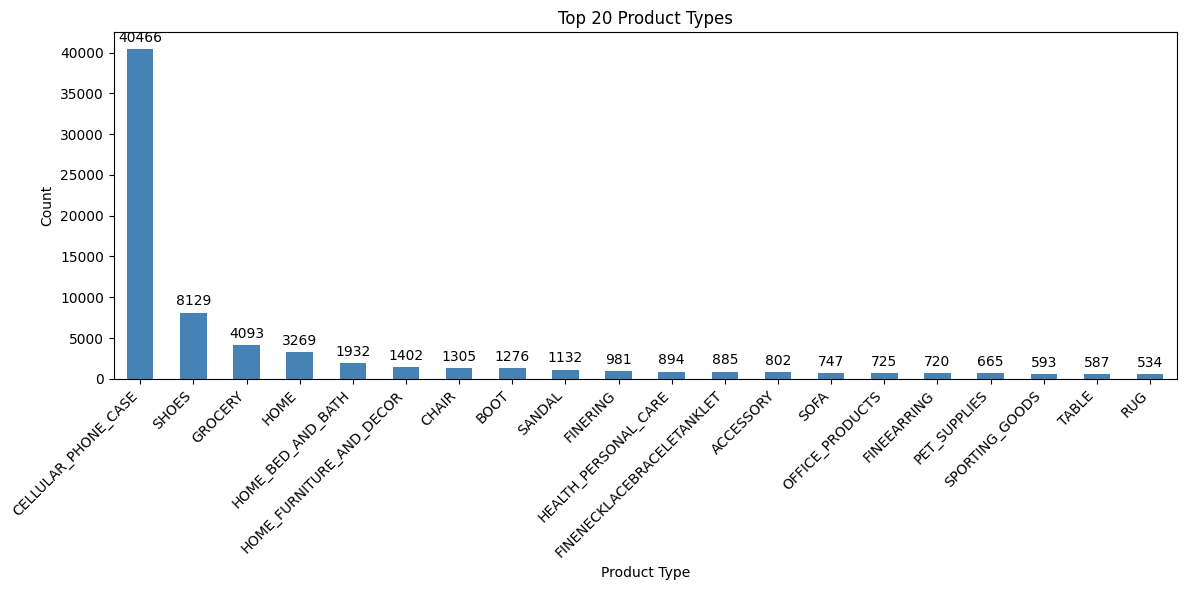

In [28]:
# visualize top 20 products!

import matplotlib.pyplot as plt

top20 = df_listings['product_type'].value_counts().head(20)
#top20 = top20.iloc[1:] # try removing cell phone case to see skew.


ax = top20.plot(kind='bar', figsize=(12, 6), color='steelblue')
ax.set_title('Top 20 Product Types')
ax.set_xlabel('Product Type')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')

ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

In [29]:
# Merge Image paths and Labels. 

# Join with existing image metadata (df_metadata) - "Label" to "Visual" join!
# 'main_image_id' in listings maps to 'image_id' in the image CSV
df_multimodal = pd.merge(
    df_listings,                             # left side - text info - Name, Brand
    df_metadata[['image_id', 'image_path']], # right side - image dictionary
    left_on='main_image_id', 
    right_on='image_id'
)

# drop redundant image_id column!
df_multimodal = df_multimodal.drop(columns=['image_id'])

In [30]:
print(f"Final dataset size: {len(df_multimodal)}")
print(df_multimodal[['item_name', 'product_type', 'image_path']].head())

Final dataset size: 91950
                                           item_name  \
0  Amazon Basics Modern Plush Standard-Pile Shag ...   
1  Amazon Brand - Solimo Designer Lake Mountain U...   
2                   Stone & Beam Andover 슬립커버 시트 컬렉션   
3                          Rivet Motion 图案羊毛跑步者, 牛仔蓝   
4  Eono MacBook Air 13 Pouces Coque 2019 2018 A19...   

                       product_type  \
0                               RUG   
1               CELLULAR_PHONE_CASE   
2          HOME_FURNITURE_AND_DECOR   
3                               RUG   
4  PORTABLE_ELECTRONIC_DEVICE_COVER   

                                          image_path  
0  /home/maulik/CS104/Final/Data/abo-images-small...  
1  /home/maulik/CS104/Final/Data/abo-images-small...  
2  /home/maulik/CS104/Final/Data/abo-images-small...  
3  /home/maulik/CS104/Final/Data/abo-images-small...  
4  /home/maulik/CS104/Final/Data/abo-images-small...  


In [31]:
sample_path = df_multimodal['image_path'].iloc[0]
print(f"Dataset Size: {len(df_multimodal)}")
print(f"Path verification: {sample_path} exists? {os.path.exists(sample_path)}")

Dataset Size: 91950
Path verification: /home/maulik/CS104/Final/Data/abo-images-small/images/small/e5/e58e6085.jpg exists? True


## Streamlining Dataset

In [32]:
# Select only the columns that provide high-value information
# Included 'brand' because AutoGluon can use it as a categorical feature

# product_type - the target (Label)
# item_name - primary text description
# image_path - the visual proof
# brand - high-level context/semantic anchor
columns_to_keep = ['product_type', 'item_name', 'image_path', 'brand']

# Filter the dataframe
df_final = df_multimodal[columns_to_keep].copy()

# Final clean-up for the 'brand' column (just in case)
df_final['brand'] = df_final['brand'].apply(extract_value)

# Quick sanity check on the final structure
print(df_final.head())

                       product_type  \
0                               RUG   
1               CELLULAR_PHONE_CASE   
2          HOME_FURNITURE_AND_DECOR   
3                               RUG   
4  PORTABLE_ELECTRONIC_DEVICE_COVER   

                                           item_name  \
0  Amazon Basics Modern Plush Standard-Pile Shag ...   
1  Amazon Brand - Solimo Designer Lake Mountain U...   
2                   Stone & Beam Andover 슬립커버 시트 컬렉션   
3                          Rivet Motion 图案羊毛跑步者, 牛仔蓝   
4  Eono MacBook Air 13 Pouces Coque 2019 2018 A19...   

                                          image_path                  brand  
0  /home/maulik/CS104/Final/Data/abo-images-small...          Amazon Basics  
1  /home/maulik/CS104/Final/Data/abo-images-small...  Amazon Brand - Solimo  
2  /home/maulik/CS104/Final/Data/abo-images-small...           Stone & Beam  
3  /home/maulik/CS104/Final/Data/abo-images-small...                  Rivet  
4  /home/maulik/CS104/Final/Data/abo-i

In [33]:
len(df_final)

91950

In [34]:
print(f"Number of unique categories to classify: {df_final['product_type'].nunique()}")

Number of unique categories to classify: 542


In [35]:
# Unfortunately, The AI can't learn a pattern from a single image; it would just be "memorizing" that one specific photo, and
# for class imblance on label doing stratify which was failing for the single item label in that category.

# Count how many items are in each category
counts = df_final['product_type'].value_counts()

# Identify categories with at least 2 items
valid_categories = counts[counts >= 2].index

# Filter the dataframe to keep only those valid categories
df_final_filtered = df_final[df_final['product_type'].isin(valid_categories)].copy()

print(f"Dropped {len(df_final) - len(df_final_filtered)} single count label items.")
print(f"Dataset Raws: {len(df_final_filtered)}")

Dropped 62 single count label items.
Dataset Raws: 91888


In [37]:
print(df_final_filtered['product_type'].value_counts().tail(10))

product_type
POWER_BANK               2
KITCHEN_TOOLS            2
NECKTIE                  2
BABY_BOTTLE              2
RECEIVER_OR_AMPLIFIER    2
PRINTER                  2
HAIR_BRUSH               2
BAKING_PAPER             2
TELESCOPE                2
MASSAGE_STICK            2
Name: count, dtype: int64


In [45]:
# How many categories have fewer than 10 examples?
small_counts = df_final_filtered['product_type'].value_counts()
small_classes = small_counts[(small_counts >= 2) & (small_counts < 10)]

print(f"Categories with 2-9 examples: {len(small_classes)}")

Categories with 2-9 examples: 183


In [46]:
print(f"Number of unique categories to classify: {df_final_filtered['product_type'].nunique()}")

Number of unique categories to classify: 480


# The Training -

In [47]:
from sklearn.model_selection import train_test_split

# use 80% for training and 20% for testing
# stratify to deal with long-tail problem and rare products represented in both train and test dataset
train_data, test_data = train_test_split(
    df_final_filtered, 
    test_size=0.2, 
    random_state=42,
    stratify=df_final_filtered['product_type'] 
)

print(f"Training on: {len(train_data)} items")
print(f"Testing on: {len(test_data)} items")

Training on: 73510 items
Testing on: 18378 items


--------------------------------------------------
PRODUCT TYPE: HAT
ITEM NAME:    BINACL Face Bandanas Balaclava, Unisex Neck Gaiter Scarf Novelty Stretchable Wind Sun UV Protection Headbands 1 Pk
BRAND:        BINACL
--------------------------------------------------


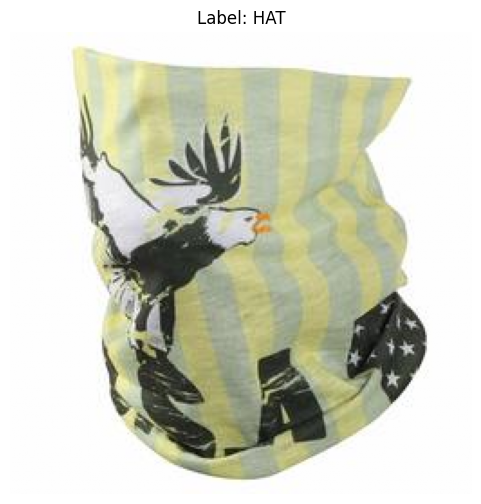

In [52]:
# Pick a random sample and view image and text - 

import matplotlib.pyplot as plt
import torchvision.io as io

# Pick a random row from your training set
sample_row = train_data.sample(1).iloc[0]

# Extract the info
p_type = sample_row['product_type']
i_name = sample_row['item_name']
brand = sample_row.get('brand', 'N/A')
img_path = sample_row['image_path']

# Load and Display
if os.path.exists(img_path):
    # read_image returns a uint8 tensor [C, H, W]
    image_tensor = io.read_image(img_path)
    
    print("-" * 50)
    print(f"PRODUCT TYPE: {p_type}")
    print(f"ITEM NAME:    {i_name}")
    print(f"BRAND:        {brand}")
    print("-" * 50)

    plt.figure(figsize=(6, 6))
    plt.imshow(image_tensor.permute(1, 2, 0).numpy() / 255.0)     # Permute to [H, W, C] and convert to float/255 for matplotlib
    plt.title(f"Label: {p_type}", fontsize=12)
    plt.axis('off')
    plt.show()
else:
    print(f"Error: Image not found at {img_path}")

In [53]:
# Reference: https://auto.gluon.ai/dev/tutorials/multimodal/advanced_topics/customization.html

from autogluon.multimodal import MultiModalPredictor

# Initialize the predictor
predictor = MultiModalPredictor(
    label='product_type', 
    problem_type='multiclass',
)

# The "Actionable" Training Run
predictor.fit(
    train_data=train_data,
    hyperparameters={
        "optim.max_epochs": 10,
        "optim.patience": 5
    },
    presets='medium_quality',  # Balanced speed and accuracy
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260505_202419"
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.19
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
CPU Count:          24
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 7.96/7.96 GB
Total GPU Memory:   Free: 7.96 GB, Allocated: 0.00 GB, Total: 7.96 GB
GPU Count:          1
Memory Avail:       9.47 GB / 15.34 GB (61.7%)
Disk Space Avail:   767.18 GB / 1006.85 GB (76.2%)

AutoMM starts to create your model. ✨✨✨

To track the learning progress, you can open a terminal and launch Tensorboard:
    ```shell
    # Assume you have installed tensorboard
    tensorboard --logdir /home/maulik/CS104/Final/AutogluonModels/ag-20260505_202419
    ```

Seed set to 0
GPU Count: 1
GPU Count to be Used: 1

Using 16bit Automatic Mixed Precision (AMP)
GPU avail

Sanity Checking: |                                                                                | 0/? [00:00…

Training: |                                                                                       | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

Epoch 0, global step 277: 'val_accuracy' reached 0.74480 (best 0.74480), saving model to '/home/maulik/CS104/Final/AutogluonModels/ag-20260505_202419/epoch=0-step=277.ckpt' as top 3


...

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting: |                                                                                     | 0/? [00:00…

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting: |                                                                                     | 0/? [00:00…

AutoMM has created your model. 🎉🎉🎉

To load the model, use the code below:
    ```python
    from autogluon.multimodal import MultiModalPredictor
    predictor = MultiModalPredictor.load("/home/maulik/CS104/Final/AutogluonModels/ag-20260505_202419")
    ```

If you are not satisfied with the model, try to increase the training time, 
adjust the hyperparameters (https://auto.gluon.ai/stable/tutorials/multimodal/advanced_topics/customization.html),
or post issues on GitHub (https://github.com/autogluon/autogluon/issues).





## Trained the model 73,510 items (name, brand, image) for 480 product types.
## Validation accuracy for predicting the Product Type: 89.32%

# Evaluation of the AI Model

In [54]:
# Final Evaluation on the Test Set
# Get the list of labels the model actually learned
known_labels = train_data['product_type'].unique()

# Filter the test set to only include those known labels
test_data_filtered = test_data[test_data['product_type'].isin(known_labels)].copy()

# If Dropped Rows = 0, means testing against known label (some instances 20% test labels were coming not seen in training for rare items).
# stratify and dropping single count product type drop shall solve the problem!
print(f"Original Test Set: {len(test_data)}")
print(f"Filtered Test Set: {len(test_data_filtered)}")
print(f"Dropped {len(test_data) - len(test_data_filtered)} rows with unseen labels.") 

# 3. Running the evaluation
test_score = predictor.evaluate(test_data_filtered)
print(f"\nFinal Test Accuracy: {test_score['accuracy']:.4f}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Original Test Set: 18378
Filtered Test Set: 18378
Dropped 0 rows with unseen labels.


Predicting: |                                                                                     | 0/? [00:00…


Final Test Accuracy: 0.8940


# Testing Accuracy (un-seen data): 89.40% 
* No signs of overfitting - generalized model for "long tail" dataset (183 categories with < 10 items)
* Stratification is sccessful

In [55]:
# Detailed Classification Report
# This tells us WHICH categories the model mastered and which it struggled with
from sklearn.metrics import classification_report

y_pred = predictor.predict(test_data)
y_true = test_data['product_type']

print("\n--- Detailed Performance Report ---")
print(classification_report(y_true, y_pred))

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting: |                                                                                     | 0/? [00:00…


--- Detailed Performance Report ---
                                   precision    recall  f1-score   support

                      ABIS_BEAUTY       0.33      0.20      0.25         5
                   ABIS_DRUGSTORE       0.60      0.35      0.44        17
                 ABIS_ELECTRONICS       1.00      0.50      0.67         2
            ABIS_HOME_IMPROVEMENT       0.00      0.00      0.00         2
                     ABIS_KITCHEN       0.00      0.00      0.00         4
             ABIS_LAWN_AND_GARDEN       0.64      0.39      0.48        18
                ABIS_PET_PRODUCTS       0.00      0.00      0.00         1
                        ACCESSORY       0.91      0.88      0.90       161
      ACCESSORY_OR_PART_OR_SUPPLY       0.64      0.80      0.71        20
                  AIR_CONDITIONER       1.00      0.25      0.40         4
                     AIR_MATTRESS       0.00      0.00      0.00         1
          AMAZON_TABLET_ACCESSORY       0.00      0.00      0.

/home/maulik/miniconda3/envs/autogluon/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maulik/miniconda3/envs/autogluon/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maulik/miniconda3/envs/autogluon/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting: |                                                                                     | 0/? [00:00…

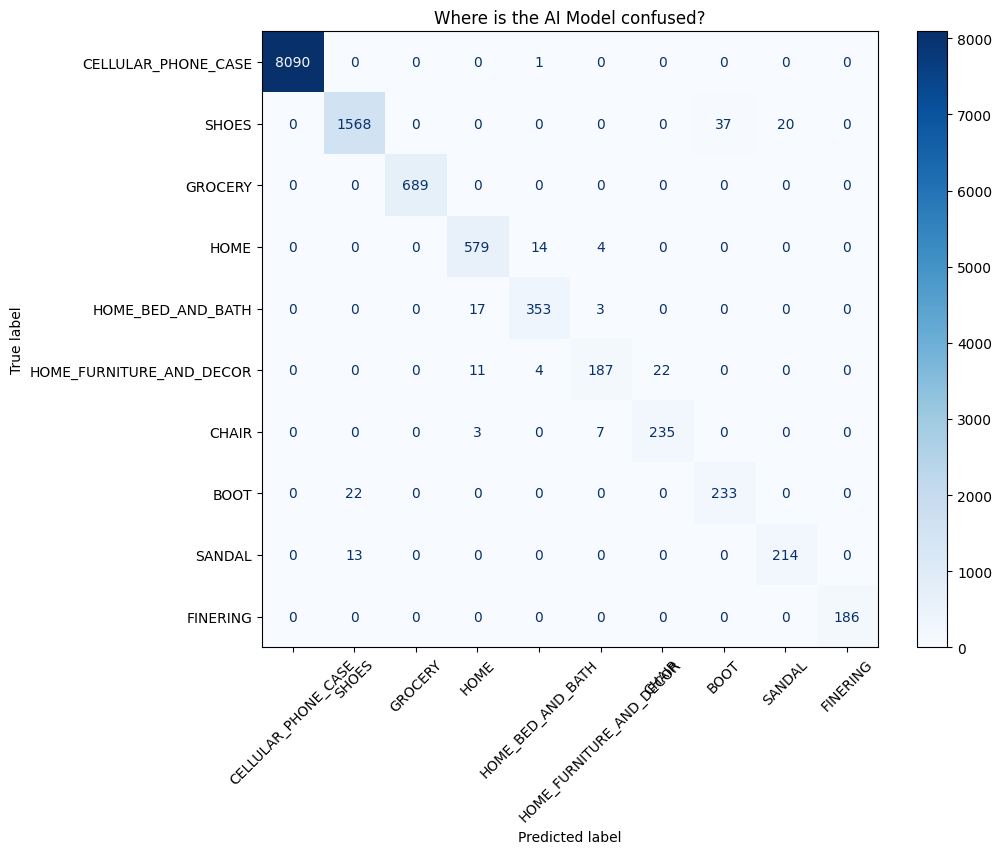

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_pred = predictor.predict(test_data_filtered)
y_true = test_data_filtered['product_type']

# Focus on the Top 10 categories for clarity
top_10_labels = y_true.value_counts().nlargest(10).index
mask = y_true.isin(top_10_labels)

# Create and plot the matrix
cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top_10_labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_10_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)
plt.title("Where is the AI Model confused?")
plt.show()

------------------------------
ITEM:      Amazon Brand - Happy Belly Roasted & Salted California Almonds, 48 Ounce
Brand:     Happy Belly
ACTUAL:    GROCERY
AI GUESSED: NUTS
PATH:      /home/maulik/CS104/Final/Data/abo-images-small/images/small/13/137320bd.jpg
------------------------------


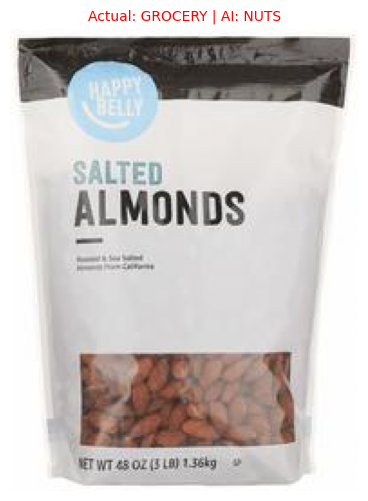

In [57]:
# Let's take one case where AI Model prediction is not correct "Mistake"! And see the details...

# Map the predictions back to our results
results = test_data_filtered.copy()
results['prediction'] = y_pred

# Look for errors in 'GROCERY'items
# We use .sample() so you can run this multiple times to see different errors
errors = results[(results['product_type'] == 'GROCERY') & (results['prediction'] != 'GROCERY')]

if not errors.empty:
    sample_error = errors.sample(1).iloc[0] # Pick a random error
    
    item_name = sample_error['item_name']
    brand     = sample_error['brand']
    
    actual = sample_error['product_type']
    prediction = sample_error['prediction']
    img_path = sample_error['image_path']
    
    print("-" * 30)
    print(f"ITEM:      {item_name}")
    print(f"Brand:     {brand}")
    print(f"ACTUAL:    {actual}")
    print(f"AI GUESSED: {prediction}")
    print(f"PATH:      {img_path}")
    print("-" * 30)

    # Display the "Mistake"
    if os.path.exists(img_path):
        image_tensor = io.read_image(img_path)
        
        plt.figure(figsize=(6, 6))
        plt.imshow(image_tensor.permute(1, 2, 0).numpy() / 255.0)
        plt.title(f"Actual: {actual} | AI: {prediction}", fontsize=10, color='red')
        plt.axis('off')
        plt.show()
    else:
        print(f"File missing at: {img_path}")
else:
    print("No errors found in this category—the model is a GROCERY Expert!")

# That's "Nuts"! AI predicted Almonds as Nuts and Label said Grocery. This is almost "human level" accuracy. Following shows the dataset with NUTS prediction. 

In [58]:
nuts = results[(results['prediction'] == 'NUTS')]

In [62]:
nuts

,product_type,item_name,image_path,brand,prediction
15782,GROCERY,Amazon Brand - Happy Belly Peanut Butter Plent...,/home/maulik/CS104/Final/Data/abo-images-small...,Happy Belly,NUTS
70275,GROCERY,Amazon Brand - Happy Belly Roasted & Salted Ca...,/home/maulik/CS104/Final/Data/abo-images-small...,Happy Belly,NUTS
67762,NUTS,"Amazon Brand - Happy Belly Deluxe Mixed Nuts, ...",/home/maulik/CS104/Final/Data/abo-images-small...,Happy Belly,NUTS


## In conclusion, this is very generalized model - 480-category Amazon product images of different dimensions classified with 89.4% accuracy. But the model hit the Semantic Ceiling of the dataset. With 480 categories, the lines between classes become blurry with some edge cases - "GROCERY and NUTS", "HOME and HOME DECOR", "SHOES and SANDLES, BOOTS". So how can model learn perfectly when ground truth has that blurriness. Also, this was with 10 Epoch training (sweet spot for running on local machine), with consolidation of similar categories and longer training, the results can made even more accurate.